In [1]:
# Import all libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

# Connect to PostgreSQL
conn = psycopg2.connect(
    host="localhost",
    database="sales_analysis",
    user="postgres",
    password="Somdo@123",  # Replace with your PostgreSQL password
    port="5432"
)

# Load data into pandas DataFrame
query = "SELECT * FROM superstore_sales"
df = pd.read_sql(query, conn)

# Quick check
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

C:\Users\gulzar\AppData\Local\Temp\ipykernel_11280\1883111247.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Shape: (9800, 20)

Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_date_clean', 'ship_date_clean']

First 3 rows:


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,order_date_clean,ship_date_clean
0,1166,CA-2015-117709,04-05-2015,08-05-2015,Standard Class,PM-18940,Paul MacIntyre,Consumer,United States,Jackson,Michigan,49201,Central,OFF-BI-10001294,Office Supplies,Binders,Fellowes Binding Cases,46.80,2015-05-04,2015-05-08
1,1254,CA-2018-144638,10-03-2018,14-03-2018,Standard Class,MH-18115,Mick Hernandez,Home Office,United States,Chester,Pennsylvania,19013,East,OFF-AR-10003958,Office Supplies,Art,Newell 337,5.25,2018-03-10,2018-03-14
2,1651,CA-2015-135699,29-08-2015,29-08-2015,Same Day,HH-15010,Hilary Holden,Corporate,United States,San Francisco,California,94110,West,OFF-PA-10004475,Office Supplies,Paper,Xerox 1940,109.92,2015-08-29,2015-08-29


In [2]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df['sales'].describe()

Data Types:
row_id                int64
order_id                str
order_date              str
ship_date               str
ship_mode               str
customer_id             str
customer_name           str
segment                 str
country                 str
city                    str
state                   str
postal_code             str
region                  str
product_id              str
category                str
sub_category            str
product_name            str
sales               float64
order_date_clean     object
ship_date_clean      object
dtype: object

Missing Values:
row_id               0
order_id             0
order_date           0
ship_date            0
ship_mode            0
customer_id          0
customer_name        0
segment              0
country              0
city                 0
state                0
postal_code         11
region               0
product_id           0
category             0
sub_category         0
product_name         0
sales 

count     9800.000000
mean       230.769079
std        626.651906
min          0.440000
25%         17.250000
50%         54.490000
75%        210.605000
max      22638.480000
Name: sales, dtype: float64

In [3]:
# Convert date columns to proper datetime
df['order_date_clean'] = pd.to_datetime(df['order_date_clean'])
df['ship_date_clean'] = pd.to_datetime(df['ship_date_clean'])

# Extract year and month for analysis
df['year'] = df['order_date_clean'].dt.year
df['month'] = df['order_date_clean'].dt.month
df['month_name'] = df['order_date_clean'].dt.strftime('%b')

print("Date columns converted successfully!")
print(df[['order_date_clean', 'year', 'month', 'month_name']].head(3))

Date columns converted successfully!
  order_date_clean  year  month month_name
0       2015-05-04  2015      5        May
1       2018-03-10  2018      3        Mar
2       2015-08-29  2015      8        Aug


In [4]:
# Fill missing postal codes with 'Unknown'
df['postal_code'] = df['postal_code'].fillna('Unknown')

print("Missing values after fix:")
print(df.isnull().sum().sum(), "total missing values remaining")

Missing values after fix:
0 total missing values remaining


In [5]:
# Set up chart styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set default figure size
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Chart styling ready!")

Chart styling ready!


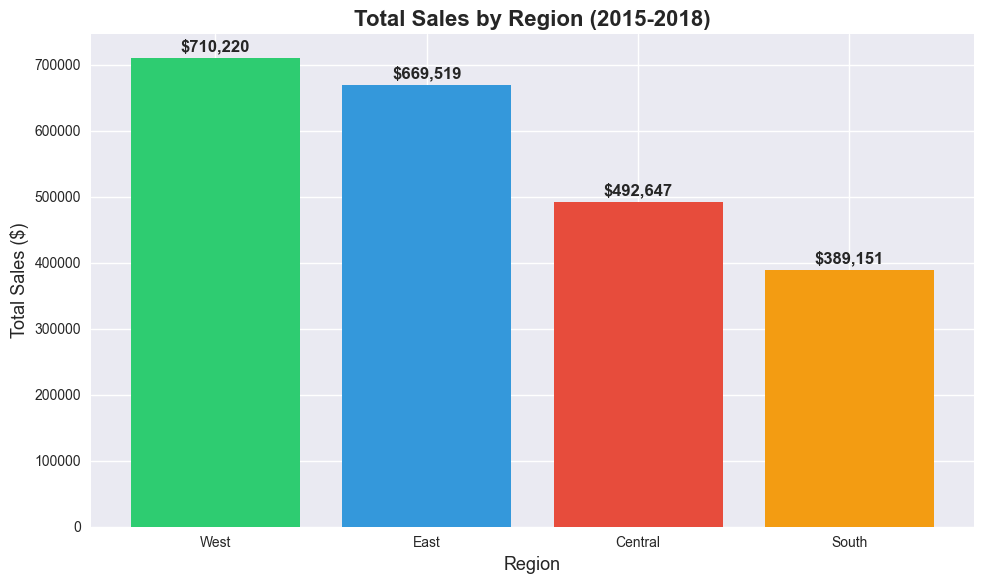

Chart 1 saved!


In [6]:
# Sales by Region
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(region_sales['region'], region_sales['sales'], 
               color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])

# Add value labels on top of bars
for bar, value in zip(bars, region_sales['sales']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.title('Total Sales by Region (2015-2018)', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=13)
plt.ylabel('Total Sales ($)', fontsize=13)
plt.tight_layout()
plt.savefig('D:/Project/python_analysis/chart1_region_sales.png', dpi=150)
plt.show()
print("Chart 1 saved!")

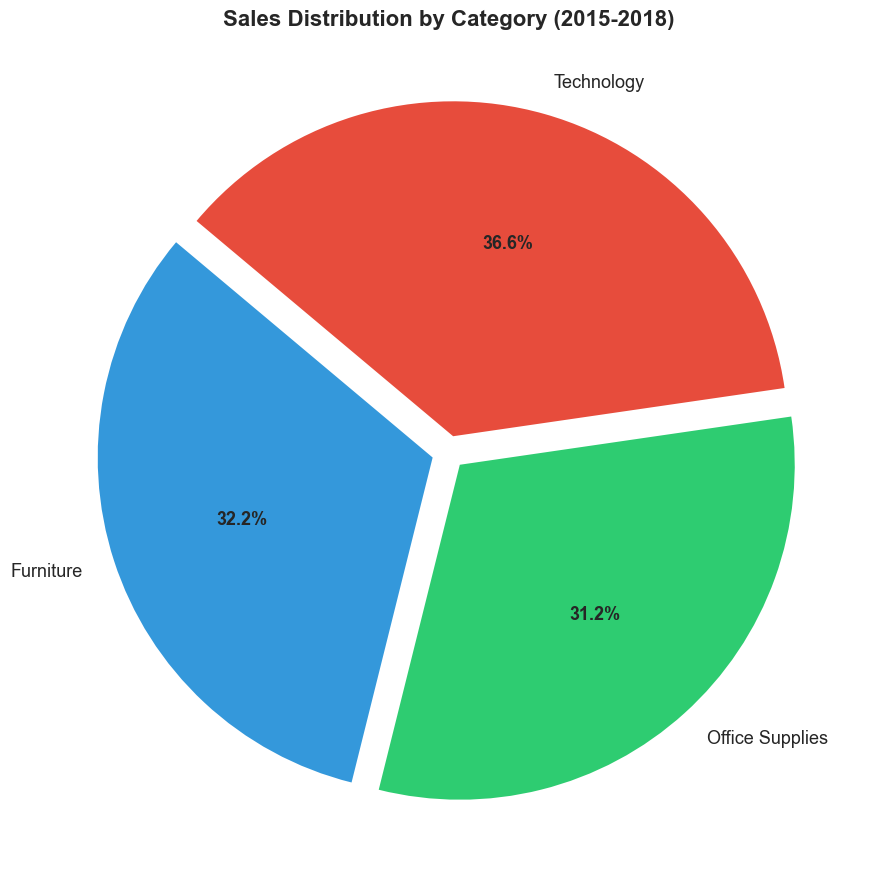

Chart 2 saved!


In [7]:
# Sales by Category - Pie Chart
category_sales = df.groupby('category')['sales'].sum()

plt.figure(figsize=(9, 9))
colors = ['#3498db', '#2ecc71', '#e74c3c']
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 13}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.title('Sales Distribution by Category (2015-2018)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Project/python_analysis/chart2_category_sales.png', dpi=150)
plt.show()
print("Chart 2 saved!")

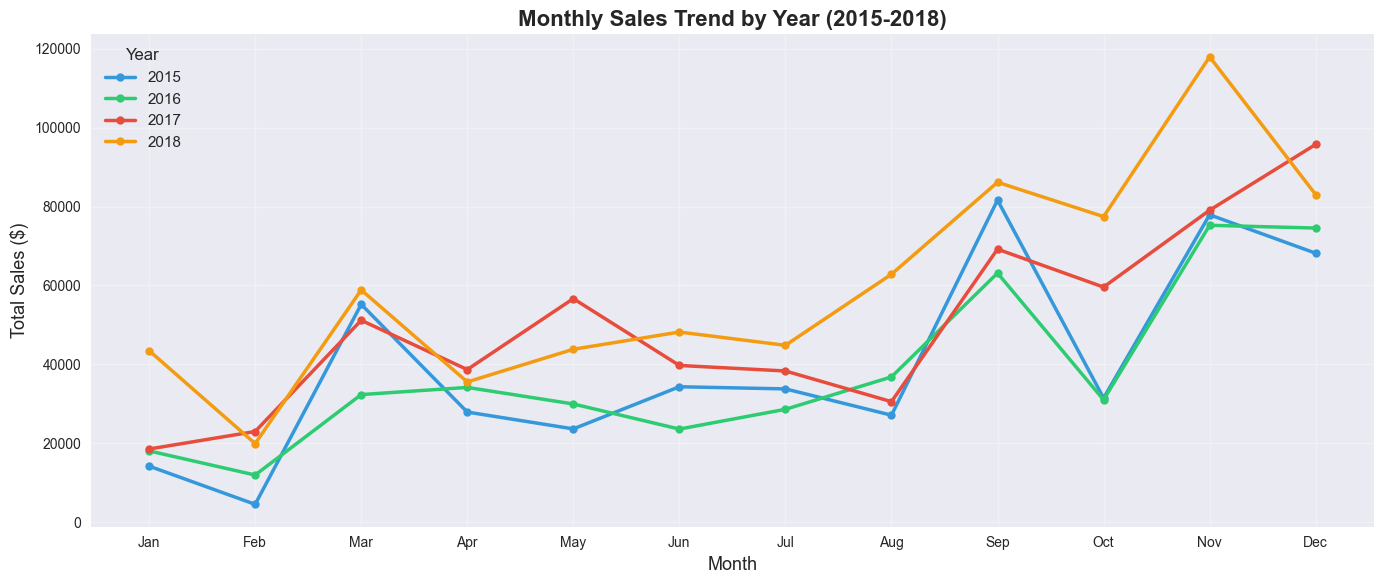

Chart 3 saved!


In [8]:
# Yearly Sales Trend
monthly_sales = df.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
years = [2015, 2016, 2017, 2018]

for year, color in zip(years, colors):
    data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(data['month'], data['sales'], 
             marker='o', linewidth=2.5, 
             markersize=6, label=str(year), color=color)

plt.title('Monthly Sales Trend by Year (2015-2018)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Total Sales ($)', fontsize=13)
plt.xticks(range(1, 13), 
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('D:/Project/python_analysis/chart3_yearly_trend.png', dpi=150)
plt.show()
print("Chart 3 saved!")

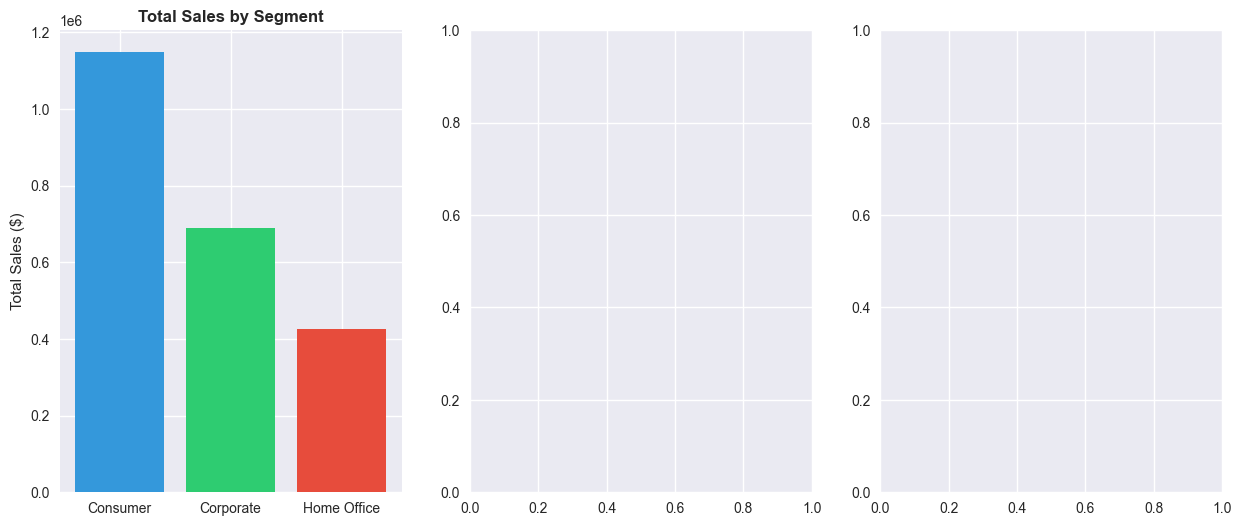

In [9]:
# Sales by Customer Segment
segment_data = df.groupby('segment').agg(
    total_sales=('sales', 'sum'),
    total_orders=('order_id', 'count'),
    unique_customers=('customer_id', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Plot 1 - Total Sales
axes[0].bar(segment_data['segment'], segment_data['total_sales'], color=colors)
axes[0].set_title('Total Sales by Segment', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
for i, v in enumerate(segment_data['total_sales']):
    axes

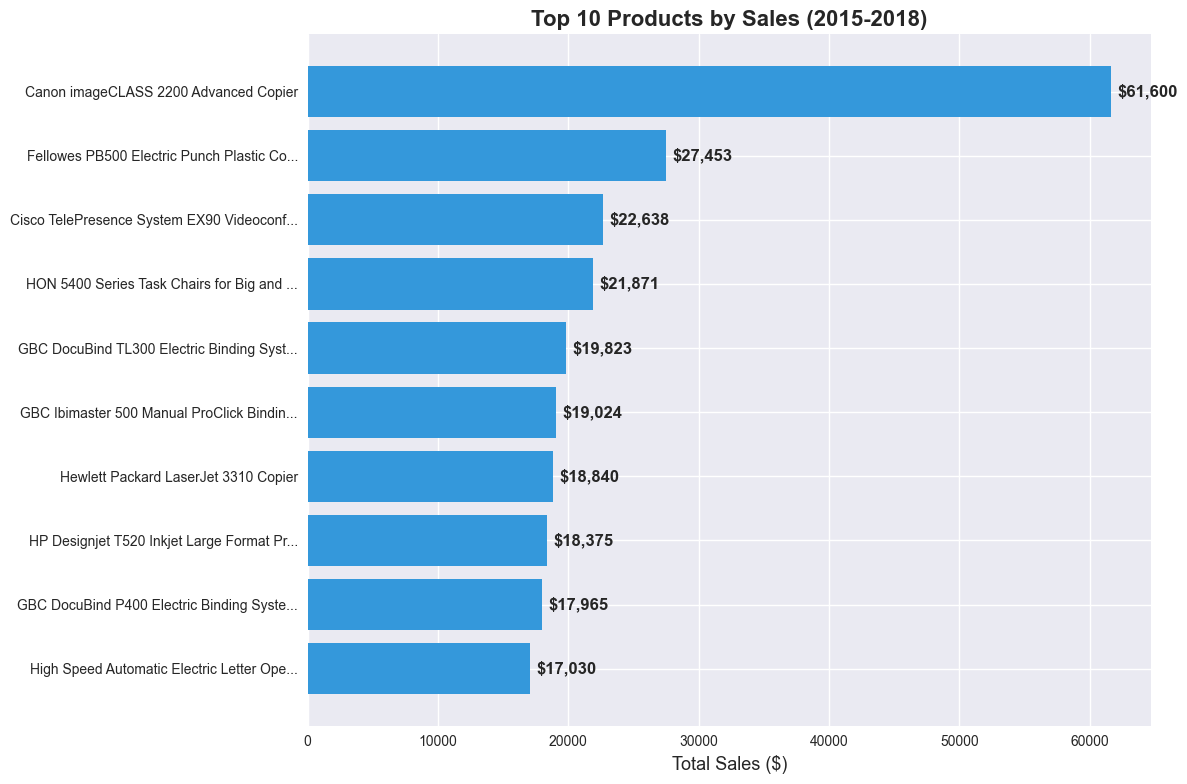

Chart 5 saved!


In [10]:
# Top 10 Products by Sales
top_products = df.groupby('product_name')['sales'].sum()\
                 .sort_values(ascending=True).tail(10)

# Shorten long product names
top_products.index = [name[:40] + '...' if len(name) > 40 
                      else name for name in top_products.index]

plt.figure(figsize=(12, 8))
bars = plt.barh(top_products.index, top_products.values, color='#3498db')

for bar, value in zip(bars, top_products.values):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${value:,.0f}', va='center', fontweight='bold')

plt.title('Top 10 Products by Sales (2015-2018)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=13)
plt.tight_layout()
plt.savefig('D:/Project/python_analysis/chart5_top_products.png', dpi=150)
plt.show()
print("Chart 5 saved!")

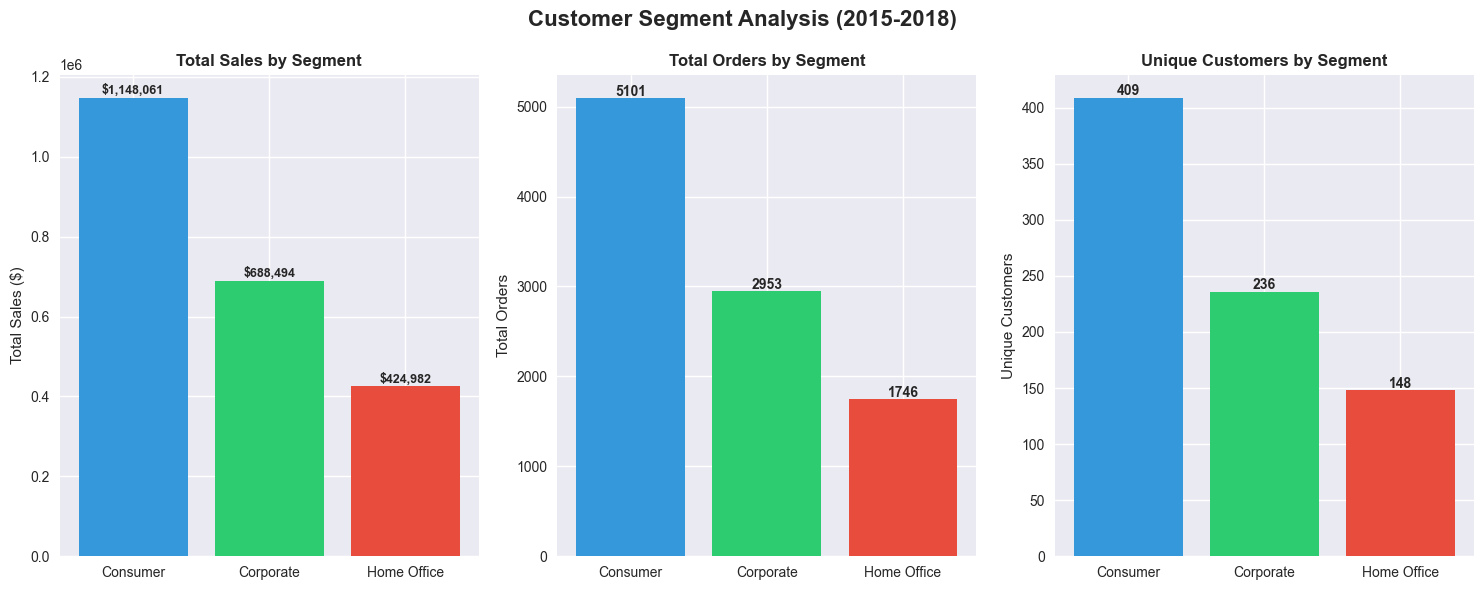

Chart 4 fixed and saved!


In [11]:
# Sales by Customer Segment - FIXED
segment_sales = df.groupby('segment')['sales'].sum().reset_index()
segment_orders = df.groupby('segment')['order_id'].count().reset_index()
segment_customers = df.groupby('segment')['customer_id'].nunique().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Plot 1 - Total Sales
axes[0].bar(segment_sales['segment'], segment_sales['sales'], color=colors)
axes[0].set_title('Total Sales by Segment', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
for i, v in enumerate(segment_sales['sales']):
    axes[0].text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Plot 2 - Total Orders
axes[1].bar(segment_orders['segment'], segment_orders['order_id'], color=colors)
axes[1].set_title('Total Orders by Segment', fontweight='bold')
axes[1].set_ylabel('Total Orders')
for i, v in enumerate(segment_orders['order_id']):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=10)

# Plot 3 - Unique Customers
axes[2].bar(segment_customers['segment'], segment_customers['customer_id'], color=colors)
axes[2].set_title('Unique Customers by Segment', fontweight='bold')
axes[2].set_ylabel('Unique Customers')
for i, v in enumerate(segment_customers['customer_id']):
    axes[2].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Customer Segment Analysis (2015-2018)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Project/python_analysis/chart4_segment_analysis.png', dpi=150)
plt.show()
print("Chart 4 fixed and saved!")